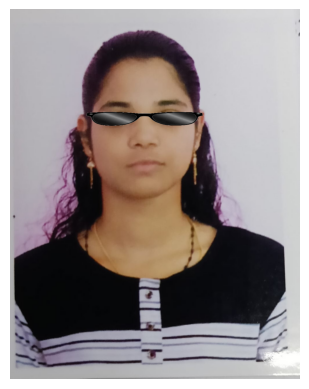

True

In [4]:
import cv2
import matplotlib.pyplot as plt

face = cv2.imread("starbiya.jpeg")
glass = cv2.imread("sunglass.png")

gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(gray, 1.1, 5)

for (x, y, w, h) in faces:

    glass_width = w
    glass_height = int(h * 0.35)

    glass_resized = cv2.resize(glass, (glass_width, glass_height))

    y_pos = y + int(h * 0.22)
    x_pos = x

    roi = face[y_pos:y_pos+glass_height,
               x_pos:x_pos+glass_width]

    gray_glass = cv2.cvtColor(glass_resized, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(
        gray_glass, 220, 255, cv2.THRESH_BINARY_INV
    )

    mask_inv = cv2.bitwise_not(mask)

    bg = cv2.bitwise_and(roi, roi, mask=mask_inv)
    fg = cv2.bitwise_and(glass_resized, glass_resized, mask=mask)

    dst = cv2.add(bg, fg)

    face[y_pos:y_pos+glass_height,
         x_pos:x_pos+glass_width] = dst

plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

cv2.imwrite("final_output.png", face)